# Snapshot comparison

The September 2025 publication remains unchanged. Re-running its fixed 50-band catalogue with Spotify metrics from 17 July 2026 leaves all ten preferred city ranks unchanged, including the top three: Sheffield, Liverpool and Manchester. Kiki Dee crosses the follower threshold, raising the eligible count from 44 to 45 and giving Bradford a second eligible band, but Bradford remains tenth.

In the ten-band scene-depth experiment, all ten city ranks are also unchanged and the largest score movement is only 0.16%. The two captures are just 2.4 hours apart, so this checks capture consistency rather than a trend.

## 01. Comparison design

Both comparisons hold the reviewed artist IDs, city assignments, catalogues and 2024 population denominators fixed. Only Spotify followers and monthly listeners change.

- Publication baseline: `data/processed/shortlist_spotify_metrics.json` (20 September 2025).
- Publication candidate: `data/processed/shortlist_spotify_metrics_20260717T225913Z.json` (17 July 2026).
- Scene-depth baseline: `data/processed/scene_depth_band_metrics_20260717T203002Z.csv`.
- Scene-depth candidate: the archived `scene_depth_band_metrics_20260717T225650Z.csv`.

The publication baseline was collected through SpotScraper; the candidate was parsed from Spotify's public artist pages. The concepts match, but a source-method change is still a comparability caveat. Monthly listeners are volatile rolling counts, and a single new snapshot should not be described as a trend.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from pandas.testing import assert_frame_equal
from IPython.display import display


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "reference" / "original_shortlist.csv").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the uk-music-cities repository")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def display_path(path: Path) -> Path:
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


from python_uk_bands.analysis import build_city_rankings
from python_uk_bands.dataset import load_shortlist_dataset, validate_shortlist_shape
from python_uk_bands.scene_depth import (
    build_scene_depth_rankings,
    validate_scene_depth_dataset,
)
from python_uk_bands.snapshot_visuals import plot_city_score_snapshot_change
from python_uk_bands.visuals import apply_chart_style

apply_chart_style()

BASELINE_SHORTLIST_PATH = PROJECT_ROOT / "data/processed/shortlist_spotify_metrics.json"
CANDIDATE_SHORTLIST_PATH = PROJECT_ROOT / "data/processed/shortlist_spotify_metrics_20260717T225913Z.json"
BASELINE_SCENE_METRICS_PATH = PROJECT_ROOT / "data/processed/scene_depth_band_metrics_20260717T203002Z.csv"
SCENE_ARCHIVE_PATH = PROJECT_ROOT / "data/snapshots/20260718T221021Z_completed-final-band-composition-and-raw-impact/files/data/processed"
CANDIDATE_SCENE_METRICS_PATH = SCENE_ARCHIVE_PATH / "scene_depth_band_metrics_20260717T225650Z.csv"
BASELINE_SCENE_RANKINGS_PATH = PROJECT_ROOT / "data/processed/scene_depth_rankings_20260717T203002Z.csv"
CANDIDATE_SCENE_RANKINGS_PATH = SCENE_ARCHIVE_PATH / "scene_depth_rankings_20260717T225650Z.csv"
CHART_OUTPUT_DIR = PROJECT_ROOT / "artifacts/snapshot_comparisons/20260717T203002Z_vs_20260717T225650Z_and_20260717T225913Z"


## 02. Data-quality and identity checks

The checks below stop execution if either catalogue changes, an artist ID changes, a city assignment changes, or a scene-depth saved ranking cannot be reproduced from its band-level file.


In [2]:
baseline_bands = load_shortlist_dataset(metrics_path=BASELINE_SHORTLIST_PATH)
candidate_bands = load_shortlist_dataset(metrics_path=CANDIDATE_SHORTLIST_PATH)
validate_shortlist_shape(baseline_bands)
validate_shortlist_shape(candidate_bands)

identity_columns = ["band", "city", "spotify_id"]
assert_frame_equal(
    baseline_bands[identity_columns].sort_values("band").reset_index(drop=True),
    candidate_bands[identity_columns].sort_values("band").reset_index(drop=True),
)
assert set(baseline_bands["population"]) == set(candidate_bands["population"])

baseline_scene_bands = pd.read_csv(BASELINE_SCENE_METRICS_PATH)
candidate_scene_bands = pd.read_csv(CANDIDATE_SCENE_METRICS_PATH)
validate_scene_depth_dataset(baseline_scene_bands, expected_cities=10, bands_per_city=10)
validate_scene_depth_dataset(candidate_scene_bands, expected_cities=10, bands_per_city=10)
assert_frame_equal(
    baseline_scene_bands[identity_columns].sort_values("band").reset_index(drop=True),
    candidate_scene_bands[identity_columns].sort_values("band").reset_index(drop=True),
)

quality_summary = pd.DataFrame(
    {
        "Check": [
            "Publication rows in each snapshot",
            "Scene-depth rows in each snapshot",
            "Fixed publication artist IDs",
            "Fixed scene-depth artist IDs",
            "Candidate follower coverage",
        ],
        "Result": [50, 100, "pass", "pass", int(candidate_bands["followers"].notna().sum())],
    }
)
display(quality_summary)


,Check,Result
0,Publication rows in each snapshot,50
1,Scene-depth rows in each snapshot,100
2,Fixed publication artist IDs,pass
3,Fixed scene-depth artist IDs,pass
4,Candidate follower coverage,50


## 03. Published 50-band method under current metrics

The publication rule is unchanged: retain bands with at least 100,000 followers, take each city's top three monthly-listener values and divide by the corresponding 2024 FUA population.


In [3]:
FOLLOWER_THRESHOLD = 100_000
TOP_N = 3

baseline_eligible = baseline_bands.loc[
    baseline_bands["followers"] >= FOLLOWER_THRESHOLD
].copy()
candidate_eligible = candidate_bands.loc[
    candidate_bands["followers"] >= FOLLOWER_THRESHOLD
].copy()
baseline_rankings = build_city_rankings(
    baseline_eligible, metric="monthly_listeners", top_n=TOP_N
)
candidate_rankings = build_city_rankings(
    candidate_eligible, metric="monthly_listeners", top_n=TOP_N
)
shortlist_comparison = (
    baseline_rankings[["city", "rank", "top_n_ratio", "eligible_bands"]]
    .merge(
        candidate_rankings[["city", "rank", "top_n_ratio", "eligible_bands"]],
        on="city",
        suffixes=("_baseline", "_candidate"),
        validate="one_to_one",
    )
)
shortlist_comparison["score_change_pct"] = (
    shortlist_comparison["top_n_ratio_candidate"]
    / shortlist_comparison["top_n_ratio_baseline"]
    - 1
) * 100
display(
    shortlist_comparison.sort_values("rank_candidate").rename(
        columns={
            "city": "City",
            "rank_baseline": "Sep 2025 rank",
            "rank_candidate": "Current rank",
            "top_n_ratio_baseline": "Sep 2025 score",
            "top_n_ratio_candidate": "Current score",
            "eligible_bands_baseline": "Sep eligible",
            "eligible_bands_candidate": "Current eligible",
            "score_change_pct": "Score change %",
        }
    )
)


,City,Sep 2025 rank,Sep 2025 score,Sep eligible,Current rank,Current score,Current eligible,Score change %
0,Sheffield,1,61.617531,5,1,63.078596,5,2.371183
1,Liverpool,2,27.010721,5,2,28.978947,5,7.286833
2,Manchester,3,20.035647,5,3,22.355272,5,11.577489
3,Birmingham,4,15.090543,5,4,15.948071,5,5.682554
4,Bristol,5,13.981073,5,5,15.669240,5,12.074661
5,Glasgow,6,12.486663,5,6,12.970385,5,3.873907
6,London,7,11.800176,5,7,11.723757,5,-0.647603
7,Nottingham,8,8.912066,4,8,6.645944,4,-25.427574
8,Leeds,9,5.799105,4,9,5.506011,4,-5.054131
9,Bradford,10,0.754497,1,10,3.207555,2,325.125060


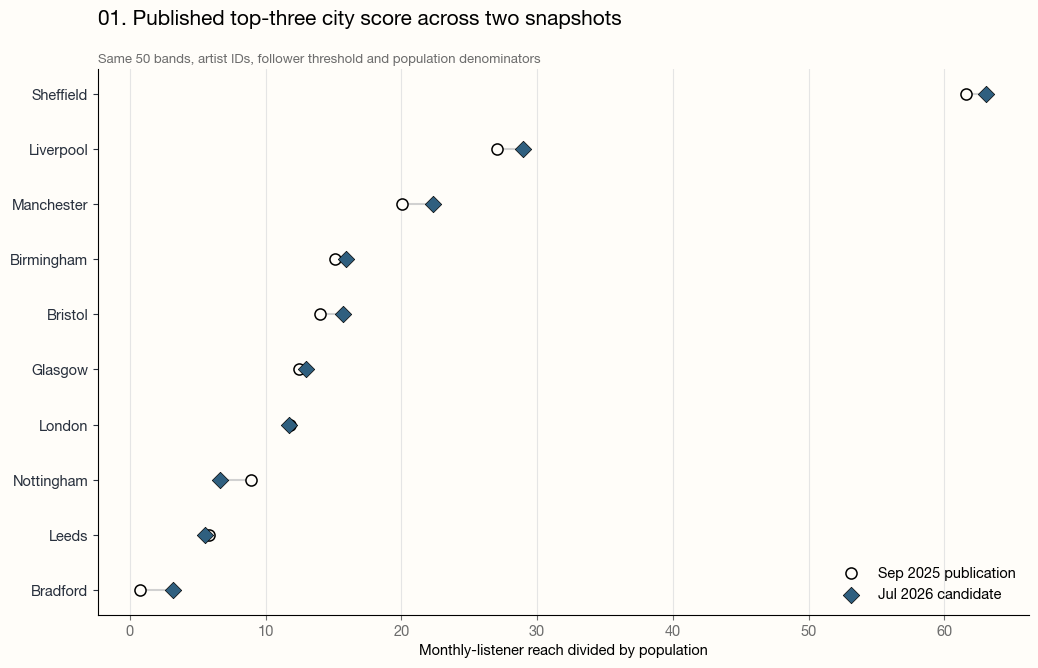

PosixPath('artifacts/snapshot_comparisons/20260717T203002Z_vs_20260717T225650Z_and_20260717T225913Z/chart_01_publication_score_change.png')

In [4]:
figure_01_path = plot_city_score_snapshot_change(
    shortlist_comparison,
    baseline_column="top_n_ratio_baseline",
    candidate_column="top_n_ratio_candidate",
    baseline_label="Sep 2025 publication",
    candidate_label="Jul 2026 candidate",
    title="Published top-three city score across two snapshots",
    subtitle="Same 50 bands, artist IDs, follower threshold and population denominators",
    x_label="Monthly-listener reach divided by population",
    number=1,
    filename="chart_01_publication_score_change.png",
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_01_path)


The preferred top three remain Sheffield, Liverpool and Manchester, and all ten city ranks are unchanged. Eligibility rises from 44 to 45 bands because Kiki Dee crosses the threshold. Bradford gains a second eligible band and a higher score but remains tenth.

### 03.01 Band-level movement

The table separates raw metric movement from the city ranking. Percentage changes can be extreme for tiny accounts, so both absolute and percentage changes are shown.


In [5]:
band_changes = (
    baseline_bands[["band", "city", "monthly_listeners", "followers"]]
    .merge(
        candidate_bands[["band", "monthly_listeners", "followers"]],
        on="band",
        suffixes=("_baseline", "_candidate"),
        validate="one_to_one",
    )
)
band_changes["monthly_change"] = (
    band_changes["monthly_listeners_candidate"]
    - band_changes["monthly_listeners_baseline"]
)
band_changes["monthly_change_pct"] = (
    band_changes["monthly_change"]
    / band_changes["monthly_listeners_baseline"].replace(0, pd.NA)
) * 100
band_changes["follower_change"] = (
    band_changes["followers_candidate"] - band_changes["followers_baseline"]
)
largest_band_movements = band_changes.loc[
    band_changes["monthly_change"].abs().nlargest(12).index
].sort_values("monthly_change", ascending=False)
display(largest_band_movements)


,band,city,monthly_listeners_baseline,followers_baseline,monthly_listeners_candidate,followers_candidate,monthly_change,monthly_change_pct,follower_change
10,Oasis,Manchester,32054080,12169549,38993195,13931085,6939115,21.648149,1761536
20,The Beatles,Liverpool,32865417,30528081,37817522,32378653,4952105,15.067830,1850572
0,The Rolling Stones,London,27136319,15601846,30644916,16647224,3508597,12.929524,1045378
6,ELO,Birmingham,14861430,4425636,18346991,4747672,3485561,23.453739,322036
2,Blur,London,10861697,3881067,14051908,4273555,3190211,29.371202,392488
1,The Clash,London,11587166,3135248,14556602,3507296,2969436,25.626939,372048
30,Def Leppard,Sheffield,8805562,5621032,10829951,6055009,2024389,22.989890,433977
12,New Order,Manchester,6810274,2447721,8755971,2650437,1945697,28.570025,202716
23,The La's,Liverpool,6860963,287698,5584504,319883,-1276459,-18.604662,32185
5,Black Sabbath,Birmingham,19891349,9635964,18340960,10708202,-1550389,-7.794288,1072238


## 04. Ten-band scene-depth snapshot consistency

The scene-depth comparison uses the same 100 bands and removes one highest and one lowest monthly-listener observation per city. Its snapshots were taken only hours apart.


In [6]:
baseline_scene_saved = pd.read_csv(BASELINE_SCENE_RANKINGS_PATH)
candidate_scene_saved = pd.read_csv(CANDIDATE_SCENE_RANKINGS_PATH)
baseline_scene_rankings = build_scene_depth_rankings(
    baseline_scene_bands,
    metric="monthly_listeners",
    trim_each_tail=1,
    expected_cities=10,
    bands_per_city=10,
)
candidate_scene_rankings = build_scene_depth_rankings(
    candidate_scene_bands,
    metric="monthly_listeners",
    trim_each_tail=1,
    expected_cities=10,
    bands_per_city=10,
)
assert_frame_equal(
    baseline_scene_rankings.loc[:, baseline_scene_saved.columns],
    baseline_scene_saved,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)
assert_frame_equal(
    candidate_scene_rankings.loc[:, candidate_scene_saved.columns],
    candidate_scene_saved,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)
scene_comparison = (
    baseline_scene_rankings[
        ["city", "rank", "population_normalized_trimmed_mean"]
    ]
    .merge(
        candidate_scene_rankings[
            ["city", "rank", "population_normalized_trimmed_mean"]
        ],
        on="city",
        suffixes=("_baseline", "_candidate"),
        validate="one_to_one",
    )
)
scene_comparison["score_change_pct"] = (
    scene_comparison["population_normalized_trimmed_mean_candidate"]
    / scene_comparison["population_normalized_trimmed_mean_baseline"]
    - 1
) * 100
display(scene_comparison.sort_values("rank_candidate"))


,city,rank_baseline,population_normalized_trimmed_mean_baseline,rank_candidate,population_normalized_trimmed_mean_candidate,score_change_pct
1,Manchester,2,2.864875,1,3.596684,25.544208
0,Sheffield,1,4.043555,2,3.138313,-22.387286
3,London,4,2.146072,3,2.845889,32.609177
2,Birmingham,3,2.285915,4,2.845533,24.481142
4,Liverpool,5,1.977953,5,2.072477,4.778849
5,Glasgow,6,1.590355,6,1.801444,13.273069
6,Bristol,7,1.062121,7,1.526600,43.731225
7,Leeds,8,0.684977,8,1.105715,61.423696
8,Nottingham,9,0.577994,9,0.589364,1.967037
9,Bradford,10,0.006645,10,0.014786,122.499264


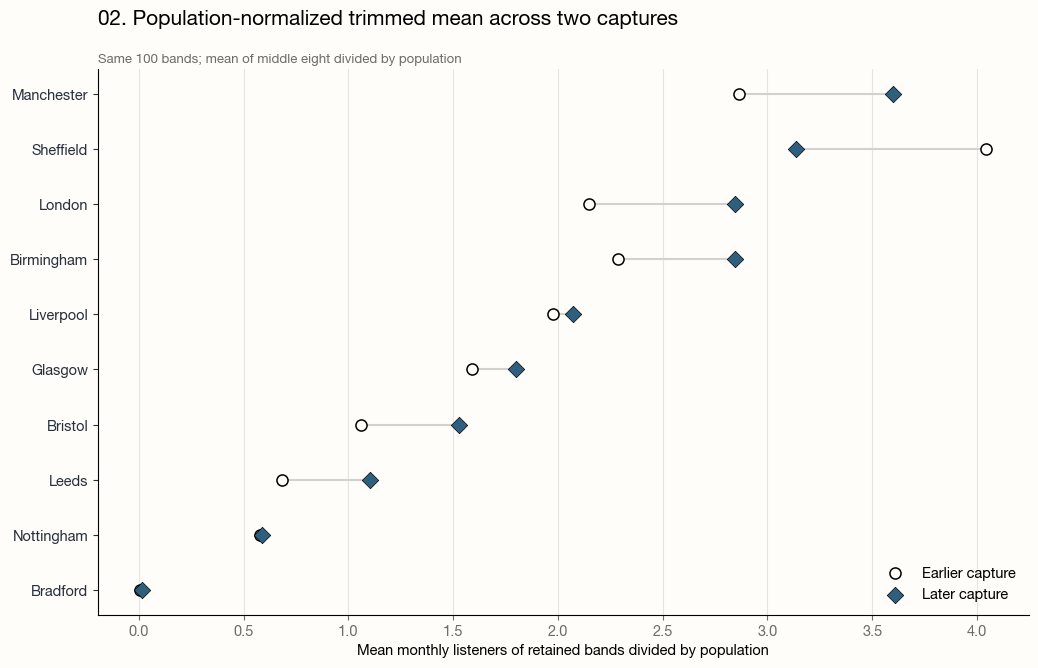

PosixPath('artifacts/snapshot_comparisons/20260717T203002Z_vs_20260717T225650Z_and_20260717T225913Z/chart_02_scene_depth_score_change.png')

In [7]:
figure_02_path = plot_city_score_snapshot_change(
    scene_comparison,
    baseline_column="population_normalized_trimmed_mean_baseline",
    candidate_column="population_normalized_trimmed_mean_candidate",
    baseline_label="Earlier capture",
    candidate_label="Later capture",
    title="Population-normalized trimmed mean across two captures",
    subtitle="Same 100 bands; mean of middle eight divided by population",
    x_label="Mean monthly listeners of retained bands divided by population",
    number=2,
    filename="chart_02_scene_depth_score_change.png",
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_02_path)


All ten ranks are unchanged. The order remains Sheffield, Manchester and Birmingham at the top, and no city's population-normalized trimmed mean moves by more than 0.16%.

## 05. Interpretation

- Keep `data/processed/shortlist_spotify_metrics.json` as the publication default.
- Use timestamped candidates for previews and comparisons; promote none of them implicitly.
- Treat the 100-band same-day comparison as evidence that the capture is reproducible, not that popularity is stable over time.
- For trend claims, collect several snapshots on a fixed cadence and distinguish threshold-crossing effects from changes among already-eligible bands.
